In [2]:
# Week 1 - Foundation
# FinSight AI - Intelligent Financial Risk & Insights Platform
# Topics: Python basics, pandas, numpy, data visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("FinSight AI - Week 1 Started ✅")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

FinSight AI - Week 1 Started ✅
pandas: 3.0.3
numpy: 2.4.4


DAY 2 - Loading and Exploring the Lending Club Dataset

In [3]:
dataset = pd.read_csv('data/loan.csv')
print("Dataset loaded successfully!")

C:\Users\DELL\AppData\Local\Temp\ipykernel_9852\614267597.py:1: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('data/loan.csv')


Dataset loaded successfully!


In [4]:
dataset.shape

(2260668, 145)

In [5]:
dataset.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5550,5550,5550.0,36 months,15.02,192.45,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,2000,2000,2000.0,36 months,17.97,72.28,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,6000,6000,6000.0,36 months,13.56,203.79,C,C1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,6000,6000,6000.0,36 months,14.47,206.44,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
dataset.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=145)

In [7]:
dataset.isna()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
1,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
3,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
4,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260664,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260665,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260666,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True


In [8]:
dataset.isna().sum()

id                       2260668
member_id                2260668
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
                          ...   
settlement_status        2227612
settlement_date          2227612
settlement_amount        2227612
settlement_percentage    2227612
settlement_term          2227612
Length: 145, dtype: int64

We can see that first and last column are entirely empty. They kind of look important.

In [9]:
dataset.isna().sum().sum()

np.int64(108666958)

What percentage of loans are defaulted?

In [10]:
dataset['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

Text(0.5, 1.0, 'Loan Count by Grade')

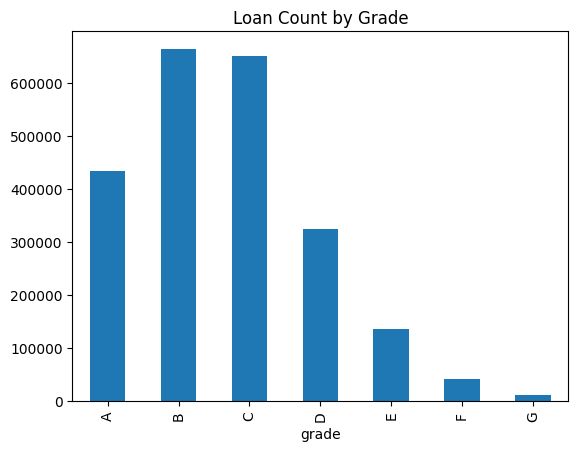

In [11]:
dataset.groupby('grade').size().plot(kind='bar')
plt.title('Loan Count by Grade')

In [12]:
dataset['loan_status'].unique()

<StringArray>
[                                            'Current',
                                          'Fully Paid',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                         'Charged Off',
                                   'Late (16-30 days)',
                                             'Default',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str

These loan statuses should be considered defaulted:

Charged Off
Default
Late (31-120 days)
Does not meet the credit policy. Status:Charged Off

In [13]:
dataset[(dataset['loan_status'] == 'Charged Off') | (dataset['loan_status'] == 'Default') | (dataset['loan_status'] == 'Late (16-30 days)') | (dataset['loan_status'] == 'Does not meet the credit policy. Status:Charged Off')]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
5040,NaN,NaN,8000,8000,8000.0,36 months,6.46,245.05,A,A1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
9620,NaN,NaN,16000,16000,16000.0,36 months,15.02,554.81,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
18860,NaN,NaN,10000,10000,10000.0,36 months,15.02,346.76,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
22225,NaN,NaN,12000,12000,12000.0,36 months,16.91,427.30,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
22452,NaN,NaN,30000,30000,30000.0,36 months,18.94,1098.78,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260633,NaN,NaN,30000,30000,29725.0,60 months,30.17,973.74,F,F3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260638,NaN,NaN,30000,30000,30000.0,36 months,21.45,1137.20,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260640,NaN,NaN,20700,20700,20700.0,60 months,12.62,466.98,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260654,NaN,NaN,30000,30000,30000.0,60 months,17.09,747.03,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
dataset['is_default'] = dataset['loan_status'].isin(['Charged Off','Late (16-30 days)','Default','Does not meet the credit policy. Status:Charged Off'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_9852\784665895.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['is_default'] = dataset['loan_status'].isin(['Charged Off','Late (16-30 days)','Default','Does not meet the credit policy. Status:Charged Off'])


In [15]:
dataset['is_default'] = dataset['is_default'].astype(int)

In [16]:
dataset['is_default'].unique()

array([0, 1])

In [17]:
dataset['is_default'].head()

0    0
1    0
2    0
3    0
4    0
Name: is_default, dtype: int64

In [18]:
dataset['is_default'].mean() * 100

np.float64(11.774572825377277)

In [19]:
dataset.groupby('grade')['is_default'].mean() * 100

grade
A     3.242985
B     7.835348
C    13.036783
D    18.640729
E    26.438561
F    34.622010
G    37.762985
Name: is_default, dtype: float64

Loan grade is a strong predictor of default — Grade G borrowers default at 11x the rate of Grade A borrowers, validating the grading system as a core risk signal.

In [20]:
dataset.drop(['NAN %', 'Empty%'], axis=1, inplace= True)

KeyError: "['NAN %', 'Empty%'] not found in axis"

Large chunk of this dataset is empty

In [ ]:
(dataset.isna().sum() / dataset.shape[0] * 100).sort_values(ascending=False).head(30)

id                       2260668
member_id                2260668
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
                          ...   
settlement_status        2227612
settlement_date          2227612
settlement_amount        2227612
settlement_percentage    2227612
settlement_term          2227612
Length: 145, dtype: int64

DATA CLEANING TODAY

In [24]:
columns_to_keep = list()
series = (dataset.isna().sum() / dataset.shape[0] * 100).sort_values(ascending=False)
for index, values in series.items():
    if values < 30:
        columns_to_keep.append(index)

print(columns_to_keep)

['mths_since_recent_inq', 'emp_title', 'num_tl_120dpd_2m', 'emp_length', 'mo_sin_old_il_acct', 'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy', 'mths_since_recent_bc', 'pct_tl_nvr_dlq', 'avg_cur_bal', 'mo_sin_old_rev_tl_op', 'num_rev_accts', 'mo_sin_rcnt_rev_tl_op', 'num_tl_30dpd', 'tot_cur_bal', 'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_op_rev_tl', 'num_rev_tl_bal_gt_0', 'num_il_tl', 'total_rev_hi_lim', 'tot_coll_amt', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'num_bc_tl', 'num_actv_rev_tl', 'tot_hi_cred_lim', 'total_il_high_credit_limit', 'num_sats', 'num_bc_sats', 'total_bal_ex_mort', 'total_bc_limit', 'acc_open_past_24mths', 'mort_acc', 'title', 'last_pymnt_d', 'revol_util', 'dti', 'pub_rec_bankruptcies', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens', 'last_credit_pull_d', 'inq_last_6mths', 'earliest_cr_line', 'open_acc', 'delinq_amnt', 'total_acc', 'acc_now_delinq', 'delinq_2yrs', 'pub_rec', 'annual_inc', 'zip_code', 'loan_amnt', '

In [ ]:
CleanData = dataset[columns_to_keep]
CleanData

,mths_since_recent_inq,emp_title,num_tl_120dpd_2m,emp_length,mo_sin_old_il_acct,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,pct_tl_nvr_dlq,...,initial_list_status,out_prncp,total_rec_prncp,total_pymnt_inv,total_pymnt,total_rec_int,collection_recovery_fee,hardship_flag,disbursement_method,debt_settlement_flag
0,2.0,Chef,0.0,10+ years,140.0,5.9,0.0,34360.0,1.0,100.0,...,w,2386.02,113.98,167.02,167.020000,53.04,0.0,N,Cash,N
1,4.0,Postmaster,0.0,10+ years,163.0,8.3,0.0,13761.0,4.0,95.0,...,w,29387.75,612.25,1507.11,1507.110000,894.86,0.0,N,Cash,N
2,14.0,Administrative,0.0,6 years,87.0,0.0,0.0,13800.0,77.0,100.0,...,w,4787.21,212.79,353.89,353.890000,141.10,0.0,N,Cash,N
3,5.0,IT Supervisor,0.0,10+ years,62.0,75.2,100.0,1239.0,64.0,100.0,...,w,3831.93,168.07,286.71,286.710000,118.64,0.0,N,Cash,N
4,13.0,Mechanic,0.0,10+ years,53.0,8.9,0.0,8471.0,2.0,92.3,...,w,29339.02,660.98,1423.21,1423.210000,762.23,0.0,N,Cash,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,9.0,house keeper,0.0,10+ years,157.0,70.9,66.7,1807.0,9.0,100.0,...,w,8687.20,3312.80,5360.96,5360.960000,2048.16,0.0,N,Cash,N
2260664,0.0,Skilled Labor,0.0,< 1 year,163.0,19.6,50.0,9162.0,141.0,76.9,...,w,0.00,12000.00,14499.80,14499.802172,2499.80,0.0,N,Cash,N
2260665,3.0,Teacher,0.0,10+ years,134.0,93.2,100.0,136.0,111.0,100.0,...,w,5993.27,4006.73,5306.94,5306.940000,1300.21,0.0,N,Cash,N
2260666,5.0,NaN,0.0,NaN,170.0,14.6,0.0,18789.0,16.0,88.2,...,w,9924.69,2075.31,5207.29,5207.290000,3131.98,0.0,N,Cash,N


In [ ]:
CleanData.shape

(2260668, 88)

In [ ]:
CleanData.columns

Index(['mths_since_recent_inq', 'emp_title', 'num_tl_120dpd_2m', 'emp_length',
       'mo_sin_old_il_acct', 'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy',
       'mths_since_recent_bc', 'pct_tl_nvr_dlq', 'avg_cur_bal',
       'mo_sin_old_rev_tl_op', 'num_rev_accts', 'mo_sin_rcnt_rev_tl_op',
       'num_tl_30dpd', 'tot_cur_bal', 'mo_sin_rcnt_tl',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_op_rev_tl',
       'num_rev_tl_bal_gt_0', 'num_il_tl', 'total_rev_hi_lim', 'tot_coll_amt',
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'num_bc_tl',
       'num_actv_rev_tl', 'tot_hi_cred_lim', 'total_il_high_credit_limit',
       'num_sats', 'num_bc_sats', 'total_bal_ex_mort', 'total_bc_limit',
       'acc_open_past_24mths', 'mort_acc', 'title', 'last_pymnt_d',
       'revol_util', 'dti', 'pub_rec_bankruptcies',
       'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens',
       'last_credit_pull_d', 'inq_last_6mths', 'earliest_cr_line', 'open_acc',
       'delinq_

In [ ]:
CleanData.drop(['title', 'zip_code'], axis=1, inplace=True)

In [ ]:
CleanData.shape

(2260668, 86)

In [ ]:
CleanData.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 86 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   mths_since_recent_inq       float64
 1   emp_title                   str    
 2   num_tl_120dpd_2m            float64
 3   emp_length                  str    
 4   mo_sin_old_il_acct          float64
 5   bc_util                     float64
 6   percent_bc_gt_75            float64
 7   bc_open_to_buy              float64
 8   mths_since_recent_bc        float64
 9   pct_tl_nvr_dlq              float64
 10  avg_cur_bal                 float64
 11  mo_sin_old_rev_tl_op        float64
 12  num_rev_accts               float64
 13  mo_sin_rcnt_rev_tl_op       float64
 14  num_tl_30dpd                float64
 15  tot_cur_bal                 float64
 16  mo_sin_rcnt_tl              float64
 17  num_accts_ever_120_pd       float64
 18  num_actv_bc_tl              float64
 19  num_op_rev_tl               floa

In [ ]:
CleanData['issue_d'].unique()

<StringArray>
['Dec-2018', 'Nov-2018', 'Oct-2018', 'Sep-2018', 'Aug-2018', 'Jul-2018',
 'Jun-2018', 'May-2018', 'Apr-2018', 'Mar-2018',
 ...
 'Dec-2007', 'Nov-2007', 'Oct-2007', 'Sep-2007', 'Aug-2007', 'Jul-2007',
 'Jun-2007', 'Dec-2017', 'Nov-2017', 'Oct-2017']
Length: 139, dtype: str

In [ ]:
CleanData['term']=CleanData['term'].str.replace(' months','')
CleanData['term']=CleanData['term'].astype(int)
CleanData['term'].dtype

dtype('int64')

In [ ]:
CleanData['last_pymnt_d']= pd.to_datetime(CleanData['last_pymnt_d'])
CleanData['last_pymnt_d']

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\2999038794.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CleanData['last_pymnt_d']= pd.to_datetime(CleanData['last_pymnt_d'])


0         2019-02-01
1         2019-02-01
2         2019-02-01
3         2019-02-01
4         2019-02-01
             ...    
2260663   2019-02-01
2260664   2018-08-01
2260665   2019-02-01
2260666   2019-02-01
2260667   2019-02-01
Name: last_pymnt_d, Length: 2260668, dtype: datetime64[us]

In [ ]:

CleanData['last_credit_pull_d']= pd.to_datetime(CleanData['last_credit_pull_d'])
CleanData['last_credit_pull_d']

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\3712060589.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CleanData['last_credit_pull_d']= pd.to_datetime(CleanData['last_credit_pull_d'])


0         2019-02-01
1         2019-02-01
2         2019-02-01
3         2019-02-01
4         2019-02-01
             ...    
2260663   2019-02-01
2260664   2017-09-01
2260665   2019-02-01
2260666   2019-02-01
2260667   2019-02-01
Name: last_credit_pull_d, Length: 2260668, dtype: datetime64[us]

In [ ]:
CleanData['earliest_cr_line'] = pd.to_datetime(CleanData['earliest_cr_line'])
CleanData['issue_d'] = pd.to_datetime(CleanData['issue_d'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\1649638134.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CleanData['earliest_cr_line'] = pd.to_datetime(CleanData['earliest_cr_line'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18748\1649638134.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CleanData['issue_d'] = pd.to_datetime(CleanData['issue_d'])


In [ ]:
CleanData.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 86 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   mths_since_recent_inq       float64       
 1   emp_title                   str           
 2   num_tl_120dpd_2m            float64       
 3   emp_length                  str           
 4   mo_sin_old_il_acct          float64       
 5   bc_util                     float64       
 6   percent_bc_gt_75            float64       
 7   bc_open_to_buy              float64       
 8   mths_since_recent_bc        float64       
 9   pct_tl_nvr_dlq              float64       
 10  avg_cur_bal                 float64       
 11  mo_sin_old_rev_tl_op        float64       
 12  num_rev_accts               float64       
 13  mo_sin_rcnt_rev_tl_op       float64       
 14  num_tl_30dpd                float64       
 15  tot_cur_bal                 float64       
 16  mo_sin_rcnt_tl              f

In [ ]:
CleanData.select_dtypes(include = str).columns.tolist()

['emp_title',
 'emp_length',
 'loan_status',
 'verification_status',
 'home_ownership',
 'sub_grade',
 'grade',
 'pymnt_plan',
 'application_type',
 'purpose',
 'addr_state',
 'initial_list_status',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

In [ ]:
annual_inc_median = CleanData['annual_inc'].median()
dti_median = CleanData['dti'].median()
revol_util_median = CleanData['revol_util'].median()
inq_last_6mths_median = CleanData['inq_last_6mths'].median()

In [ ]:
CleanData['annual_inc']=CleanData['annual_inc'].fillna(annual_inc_median)
CleanData['dti']=CleanData['dti'].fillna(dti_median)
CleanData['revol_util']=CleanData['revol_util'].fillna(revol_util_median)
CleanData['inq_last_6mths']=CleanData['inq_last_6mths'].fillna(inq_last_6mths_median)

In [ ]:
CleanData['annual_inc'].isna().sum()


np.int64(0)

In [ ]:
CleanData.to_csv('data/clean_loan_data.csv', index=False)

DAY 4 - Using Numpy to get statistics

In [25]:
df = pd.read_csv('data/clean_loan_data.csv')

In [ ]:
df['loan_amnt'].dtype 

dtype('int64')

In [ ]:
loan_amnt_mean = np.mean(df['loan_amnt'])
loan_amnt_median = np.median(df['loan_amnt'])
loan_amnt_std = np.std(df['loan_amnt'])
loan_amnt_25p = np.percentile(df['loan_amnt'],25)
loan_amnt_50p = np.percentile(df['loan_amnt'],50)
loan_amnt_75p = np.percentile(df['loan_amnt'],75)

print("Mean: ",loan_amnt_mean)
print("Median: ", loan_amnt_median)
print("Standar Deviation: ", loan_amnt_std)
print("25 Percentile: ", loan_amnt_25p)
print("50 Percentile: ", loan_amnt_50p)
print("75 Percentile: ", loan_amnt_75p)

Mean:  15046.931227849467
Median:  12900.0
Standar Deviation:  9190.243455593203
25 Percentile:  8000.0
50 Percentile:  12900.0
75 Percentile:  20000.0


Mean (15,046) is higher than Median (12,900) — this means the distribution is right-skewed. A few very large loans are pulling the mean up.
25th percentile is 8,000 and 75th is 20,000 — so the middle 50% of loans are between $8K and $20K
Standard deviation of 9,190 is quite large — there's a wide spread in loan amounts

This right-skew insight is important — it means a small number of borrowers are taking very large loans, which could represent higher risk.

In [39]:
df['is_default'] = df['loan_status'].isin(['Charged Off','Late (16-30 days)','Default','Does not meet the credit policy. Status:Charged Off'])


In [40]:
df['is_default'] = df['is_default'].astype(int)

In [ ]:
default_avg_loan_amnt = np.mean(df[df['is_default'] ==1]['loan_amnt'])
nodefault_avg_loan_amnt = np.mean(df[df['is_default'] ==0]['loan_amnt'])
print(default_avg_loan_amnt)
print(nodefault_avg_loan_amnt)

15551.92874102125
14979.534217872893


Defaulters borrow slightly more ($15,551) than non-defaulters ($14,979), about $570 more on average.
The difference isn't massive but it's consistent with what you'd expect, people who borrow more are slightly more likely to struggle with repayment.
This will become a feature in our ML model later.

In [ ]:
default_avg_interest_rate = np.mean(df[df['is_default'] ==1]['int_rate'])
nodefault_avg_interest_rate = np.mean(df[df['is_default'] ==0]['int_rate'])
std_interest_rate = np.std(df['int_rate'])
print(default_avg_interest_rate)
print(nodefault_avg_interest_rate)
print(std_interest_rate)

15.705964445646622
12.74417487430333
4.832113164136204


Defaulters pay 15.7% interest vs non-defaulters at 12.7%, that's a 3% difference. This is huge in credit risk terms.
It tells us two things:

Lenders already sensed these borrowers were riskier and charged them more
But higher interest rates also make repayment harder — creating a self-fulfilling cycle

int_rate will likely be one of the top features in our ML model. Remember this when we get to Week 3.

In [ ]:
default_avg_dti = np.mean(df[df['is_default'] ==1]['dti'])
nodefault_avg_dti = np.mean(df[df['is_default'] ==0]['dti'])
print(default_avg_dti)
print(nodefault_avg_dti)


20.14212345595528
18.647461478758412


In [ ]:
(df[df['dti']>30].value_counts().shape[0]/ df.shape[0] * 100)

8.202575521925377

Defaulters have higher DTI (20.14) vs non-defaulters (18.64), confirms DTI is a risk signal
Only 8.2% of borrowers have DTI above 30, these are our highest risk borrowers

Three patterns are emerging across our analysis:

Defaulters borrow more
Defaulters pay higher interest rates
Defaulters have higher DTI

These 3 variables together are telling a clear story, and they'll be the backbone of our risk model in Week 3.

In [ ]:
default_avg_annual_inc = np.mean(df[df['is_default'] ==1]['annual_inc'])
nodefault_avg_annual_inc = np.mean(df[df['is_default'] ==0]['annual_inc'])

print(default_avg_annual_inc)
print(nodefault_avg_annual_inc)

70452.26621476121
78998.71333904409


In [ ]:
default_median_annual_inc = np.median(df[df['is_default'] ==1]['annual_inc'])
nodefault_median_annual_inc = np.median(df[df['is_default'] ==0]['annual_inc'])

print(default_median_annual_inc)
print(nodefault_median_annual_inc)

60000.0
65025.36


In [ ]:
print(np.percentile(df['annual_inc'],90))

130000.0


So 90% of borrowers earn less than $130,000. That means anyone above $130K is in the top 10% of earners in this dataset.

Every single metric points in the same direction, defaulters borrow more, pay higher rates, have higher debt burden, and earn less. This is your first complete risk profile.

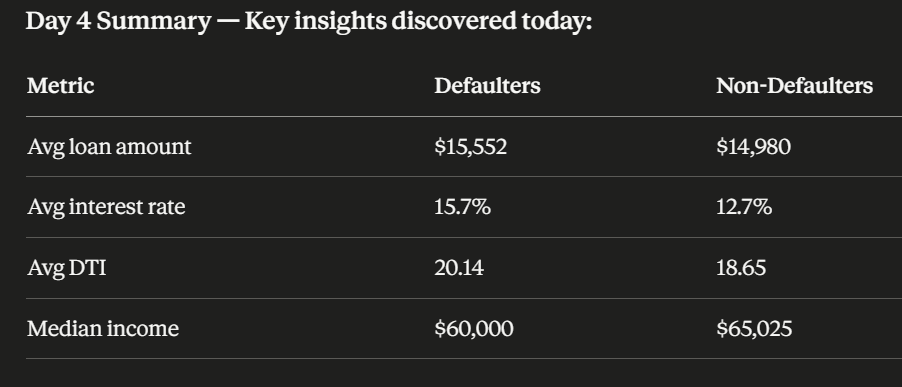

Day 5 — Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

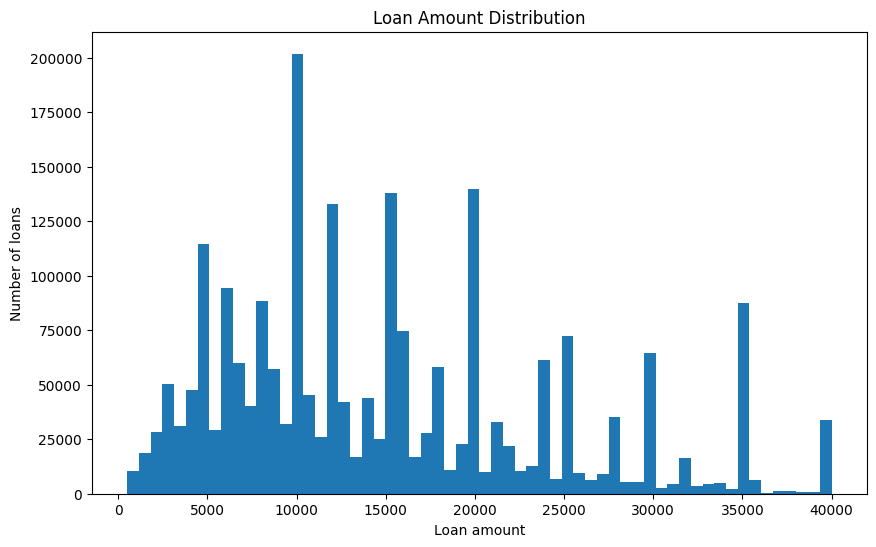

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['loan_amnt'], bins=60)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan amount')
plt.ylabel('Number of loans')
plt.savefig('reports/loan_amount_distribution.png')
plt.show()

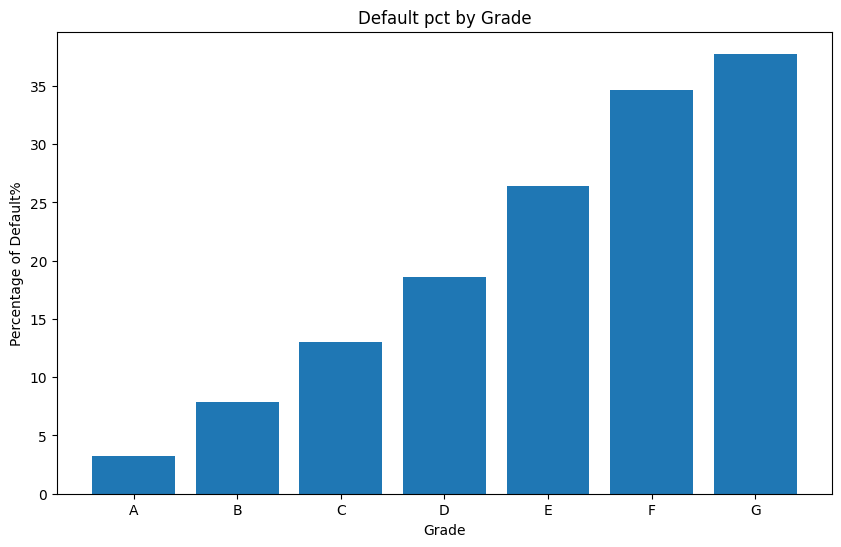

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(['A','B','C','D','E','F','G'],[3.242985,7.835348,13.036783,18.640729,26.438561,34.622010,37.762985] )
plt.title('Default pct by Grade')
plt.xlabel('Grade')
plt.ylabel('Percentage of Default%')
plt.savefig('reports/pctng_distribution.png')
plt.show()


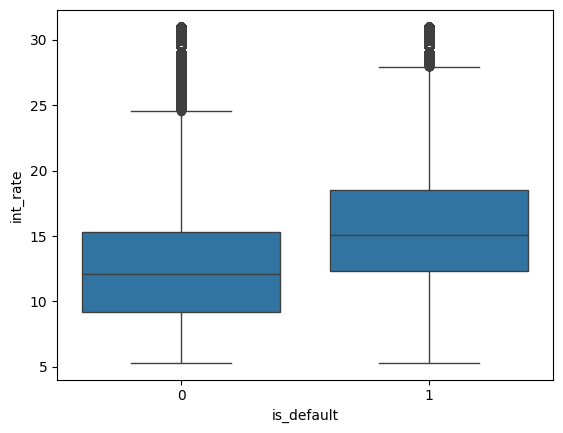

In [ ]:
sns.boxplot(x='is_default', y='int_rate', data=df)
plt.savefig('reports/boxplot_isdefault_intrate')


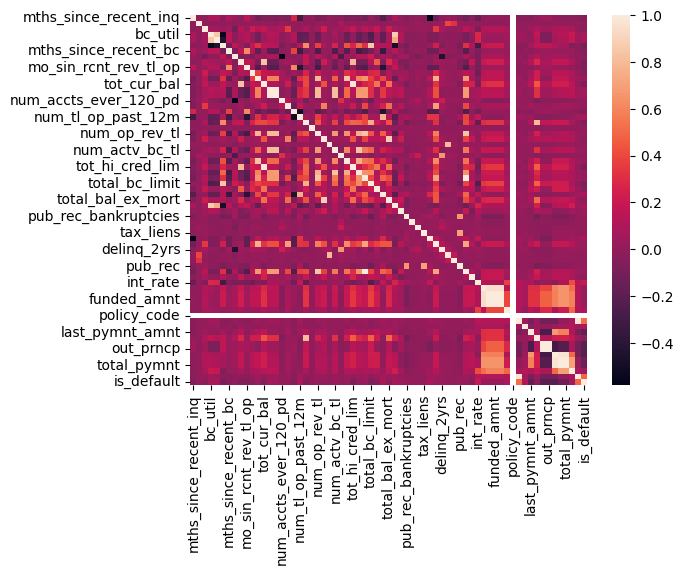

<Figure size 2000x1600 with 0 Axes>

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False)
plt.figure(figsize=(20,16))
plt.savefig('reports/correlation_heatmap.png')

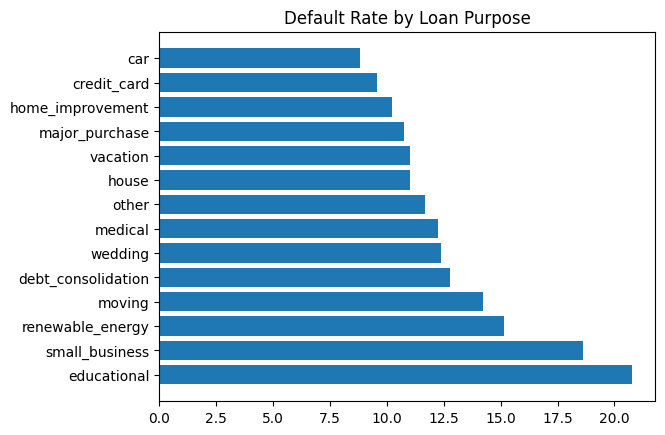

<Figure size 640x480 with 0 Axes>

In [ ]:
temp_list1 = list()
temp_list2 = list()
temp_list1 =(df.groupby(df['purpose'])['is_default'].mean()*100).sort_values(ascending=False).index
temp_list2 =(df.groupby(df['purpose'])['is_default'].mean()*100).sort_values(ascending=False).values
plt.barh(temp_list1,temp_list2)
plt.title("Default Rate by Loan Purpose")
plt.show()
plt.savefig('reports/default_rate_by_purpose.png')

In [ ]:
df.select_dtypes(include='number').corr()

,mths_since_recent_inq,num_tl_120dpd_2m,mo_sin_old_il_acct,bc_util,percent_bc_gt_75,bc_open_to_buy,mths_since_recent_bc,pct_tl_nvr_dlq,avg_cur_bal,mo_sin_rcnt_rev_tl_op,...,last_pymnt_amnt,revol_bal,out_prncp_inv,out_prncp,total_rec_prncp,total_pymnt_inv,total_pymnt,total_rec_int,collection_recovery_fee,is_default
mths_since_recent_inq,1.000000,0.000361,-0.015480,0.084705,0.079022,-0.022846,0.095210,0.030861,-0.016312,0.156183,...,-0.038008,0.010875,0.041010,0.041005,-0.005113,-0.015956,-0.015943,-0.032810,-0.034797,-0.059728
num_tl_120dpd_2m,0.000361,1.000000,0.005663,-0.007131,-0.007377,0.000747,0.005020,-0.017178,0.005356,0.002480,...,0.003069,-0.003073,-0.009103,-0.009102,0.004566,0.005184,0.005194,0.004519,0.001890,0.003677
mo_sin_old_il_acct,-0.015480,0.005663,1.000000,0.061342,0.056766,0.030260,0.056237,-0.104446,0.119064,0.037555,...,0.046787,0.104301,0.040009,0.040001,0.099209,0.105625,0.105612,0.080042,0.008528,-0.017958
bc_util,0.084705,-0.007131,0.061342,1.000000,0.846756,-0.541888,0.149961,-0.031443,0.076732,0.126862,...,0.004424,0.178343,-0.067463,-0.067467,0.082969,0.128139,0.128177,0.203734,0.045773,0.074630
percent_bc_gt_75,0.079022,-0.007377,0.056766,0.846756,1.000000,-0.440061,0.153076,-0.015105,0.067686,0.124007,...,0.003451,0.142329,-0.075658,-0.075665,0.060478,0.102895,0.102928,0.180406,0.044805,0.077130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
total_pymnt_inv,-0.015956,0.005184,0.105625,0.128139,0.102895,0.066824,0.025216,0.053129,0.172195,0.018902,...,0.583789,0.236493,-0.230160,-0.230166,0.966391,1.000000,0.999394,0.696212,0.008067,-0.132716
total_pymnt,-0.015943,0.005194,0.105612,0.128177,0.102928,0.066778,0.025205,0.053107,0.172168,0.018890,...,0.583748,0.236770,-0.231004,-0.231009,0.967017,0.999394,1.000000,0.696466,0.008305,-0.132628
total_rec_int,-0.032810,0.004519,0.080042,0.203734,0.180406,-0.058570,0.017309,0.013677,0.091425,0.007441,...,0.105523,0.175687,0.092770,0.092776,0.501711,0.696212,0.696466,1.000000,0.076768,0.041130
collection_recovery_fee,-0.034797,0.001890,0.008528,0.045773,0.044805,-0.029362,-0.023390,0.000196,-0.002577,-0.027969,...,-0.082234,0.021461,-0.104699,-0.104709,-0.099508,0.008067,0.008305,0.076768,1.000000,0.486541


WEEK 2

Right now our workflow is:
CSV file → pandas → analysis
In real companies it's:
Database → Python → analysis
Today we bridge that gap.

In [21]:
import sqlite3

In [22]:
conn = sqlite3.connect('data/finsight.db')

In [43]:
df.to_sql('loans', conn, if_exists='replace', index=False)

2260668

In [27]:
pd.read_sql("SELECT COUNT(*) as total_loans FROM loans", conn)

,total_loans
0,2260668


Below table showing count of loans per grade. Why? Because we get an idea that if that number is falling in grade A, it is comparatively safe and opposite for latter grades like E and G

In [32]:
pd.read_sql("SELECT grade, COUNT(*) as total_loans FROM loans GROUP BY grade", conn)

,grade,total_loans
0,A,433027
1,B,663557
2,C,650053
3,D,324424
4,E,135639
5,F,41800
6,G,12168


In [31]:
total_loans_by_grade = pd.read_sql("SELECT grade, COUNT(*) as total_loans FROM loans GROUP BY grade", conn)

Below table showing average intrest rate by grade, AS high we go, interest rate gets lower.

In [34]:
pd.read_sql("SELECT grade, AVG(int_rate) as avg_int_rate FROM loans GROUP BY grade", conn)

,grade,avg_int_rate
0,A,7.084558
1,B,10.675819
2,C,14.143793
3,D,18.143304
4,E,21.829848
5,F,25.454203
6,G,28.074255


In [35]:
avg_int_rate_bygrade = pd.read_sql("SELECT grade, AVG(int_rate) as avg_int_rate FROM loans GROUP BY grade", conn)

Below is the table showing default rate by purpose, we can see which purpose is more likely to get defaulted.

In [36]:
pd.read_sql("SELECT purpose, AVG(is_default)*100 as avg_int_rate FROM loans GROUP BY purpose", conn)

DatabaseError: Execution failed on sql 'SELECT purpose, AVG(is_default)*100 as avg_int_rate FROM loans GROUP BY purpose': no such column: is_default

Oops! I might got the wrong column name. Edit: I forgot to re-execute the code where 'is-default' column was added in the database.

In [42]:
df.columns

Index(['mths_since_recent_inq', 'emp_title', 'num_tl_120dpd_2m', 'emp_length',
       'mo_sin_old_il_acct', 'bc_util', 'percent_bc_gt_75', 'bc_open_to_buy',
       'mths_since_recent_bc', 'pct_tl_nvr_dlq', 'avg_cur_bal',
       'mo_sin_rcnt_rev_tl_op', 'mo_sin_old_rev_tl_op', 'num_rev_accts',
       'tot_cur_bal', 'num_rev_tl_bal_gt_0', 'num_actv_rev_tl',
       'num_accts_ever_120_pd', 'num_il_tl', 'mo_sin_rcnt_tl',
       'num_tl_op_past_12m', 'total_rev_hi_lim', 'tot_coll_amt',
       'num_op_rev_tl', 'total_il_high_credit_limit', 'num_tl_30dpd',
       'num_actv_bc_tl', 'num_tl_90g_dpd_24m', 'num_bc_tl', 'tot_hi_cred_lim',
       'num_bc_sats', 'num_sats', 'total_bc_limit', 'mort_acc',
       'acc_open_past_24mths', 'total_bal_ex_mort', 'last_pymnt_d',
       'revol_util', 'dti', 'pub_rec_bankruptcies',
       'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens',
       'last_credit_pull_d', 'inq_last_6mths', 'total_acc', 'delinq_2yrs',
       'acc_now_delinq', 'de

In [45]:
pd.read_sql("SELECT purpose, AVG(is_default) * 100 as default_pct FROM loans GROUP BY purpose", conn)

,purpose,default_pct
0,car,8.811894
1,credit_card,9.559530
2,debt_consolidation,12.796928
3,educational,20.754717
4,home_improvement,10.240800
5,house,11.028580
6,major_purchase,10.742393
7,medical,12.252619
8,moving,14.218009
9,other,11.668101


In [46]:
default_pct_by_purpose=pd.read_sql("SELECT purpose, AVG(is_default) * 100 as default_pct FROM loans GROUP BY purpose", conn)

In [47]:
df['addr_state']

0          NY
1          LA
2          MI
3          WA
4          MD
           ..
2260663    VT
2260664    OR
2260665    IL
2260666    AK
2260667    NY
Name: addr_state, Length: 2260668, dtype: str

Total loan by state here. We get an idea where most amount of loan is going.

In [50]:
pd.read_sql("SELECT addr_state, SUM(loan_amnt) as total_amnt FROM loans GROUP BY addr_state ORDER BY SUM(loan_amnt)DESC LIMIT 10", conn)

,addr_state,total_amnt
0,CA,4808480100
1,TX,2931133525
2,NY,2767160700
3,FL,2333034500
4,IL,1410451950
5,NJ,1316207975
6,GA,1136790825
7,PA,1131987950
8,OH,1077142925
9,VA,1013015875


In [51]:
top_10_states_with_highest_loan_amnt = pd.read_sql("SELECT addr_state, SUM(loan_amnt) as total_amnt FROM loans GROUP BY addr_state ORDER BY SUM(loan_amnt)DESC LIMIT 10", conn)

Count of high risk loan. We define high risk if interest rate is above 20 and debt-to-income ratio is above 30 

In [52]:
pd.read_sql("SELECT COUNT(*) AS count_high_risk_loan FROM loans WHERE int_rate>20 AND dti>30", conn)

,count_high_risk_loan
0,34009
